In [4]:
import pandas as pd

spy = pd.read_excel("SPY_daily_close_Jan2016_Sept2026.xlsx")
qqq = pd.read_excel("QQQ_daily_close_Jan2016_Sept2026.xlsx")
tlt = pd.read_excel("TLT_daily_close_Jan2016_Sept2026.xlsx")
gld = pd.read_excel("GLD_daily_close_Jan2016_Sept2026.xlsx")
vnq = pd.read_excel("VNQ_daily_close_Jan2016_Sept2026.xlsx")

In [5]:
spy.head()

,Date,Close
0,2016-01-04,201.02
1,2016-01-05,201.36
2,2016-01-06,198.82
3,2016-01-07,194.05
4,2016-01-08,191.92


In [6]:
print("SPY:", len(spy))
print("QQQ:", len(qqq))
print("TLT:", len(tlt))
print("GLD:", len(gld))
print("VNQ:", len(vnq))

SPY: 2684
QQQ: 2684
TLT: 2684
GLD: 2684
VNQ: 2684


In [7]:
data = pd.merge(
    spy,
    qqq,
    on="Date",
    suffixes=("_SPY", "_QQQ")
)

data.head()

,Date,Close_SPY,Close_QQQ
0,2016-01-04,201.02,109.50
1,2016-01-05,201.36,109.31
2,2016-01-06,198.82,108.26
3,2016-01-07,194.05,104.87
4,2016-01-08,191.92,104.01


In [8]:
data.shape

(2684, 3)

In [9]:
data = pd.merge(data, tlt, on="Date")
data = pd.merge(data, gld, on="Date")
data = pd.merge(data, vnq, on="Date")

data.head()

,Date,Close_SPY,Close_QQQ,Close_x,Close_y,Close
0,2016-01-04,201.02,109.50,121.45,102.89,78.77
1,2016-01-05,201.36,109.31,120.96,103.18,80.29
2,2016-01-06,198.82,108.26,122.59,104.67,80.07
3,2016-01-07,194.05,104.87,122.81,106.15,78.51
4,2016-01-08,191.92,104.01,123.36,105.68,77.46


In [10]:
tlt = tlt.rename(columns={"Close": "TLT"})
gld = gld.rename(columns={"Close": "GLD"})
vnq = vnq.rename(columns={"Close": "VNQ"})

data = pd.merge(data, tlt, on="Date")
data = pd.merge(data, gld, on="Date")
data = pd.merge(data, vnq, on="Date")

data.head()

,Date,Close_SPY,Close_QQQ,Close_x,Close_y,Close,TLT,GLD,VNQ
0,2016-01-04,201.02,109.50,121.45,102.89,78.77,121.45,102.89,78.77
1,2016-01-05,201.36,109.31,120.96,103.18,80.29,120.96,103.18,80.29
2,2016-01-06,198.82,108.26,122.59,104.67,80.07,122.59,104.67,80.07
3,2016-01-07,194.05,104.87,122.81,106.15,78.51,122.81,106.15,78.51
4,2016-01-08,191.92,104.01,123.36,105.68,77.46,123.36,105.68,77.46


In [11]:
data = pd.merge(
    spy.rename(columns={"Close": "SPY"}),
    qqq.rename(columns={"Close": "QQQ"}),
    on="Date"
)

data = pd.merge(data, tlt, on="Date")
data = pd.merge(data, gld, on="Date")
data = pd.merge(data, vnq, on="Date")

data.head()

,Date,SPY,QQQ,TLT,GLD,VNQ
0,2016-01-04,201.02,109.50,121.45,102.89,78.77
1,2016-01-05,201.36,109.31,120.96,103.18,80.29
2,2016-01-06,198.82,108.26,122.59,104.67,80.07
3,2016-01-07,194.05,104.87,122.81,106.15,78.51
4,2016-01-08,191.92,104.01,123.36,105.68,77.46


In [12]:
data.isna().sum()

Date    0
SPY     0
QQQ     0
TLT     0
GLD     0
VNQ     0
dtype: int64

In [13]:
data["Date"] = pd.to_datetime(data["Date"])

In [14]:
data.dtypes

Date    datetime64[ns]
SPY            float64
QQQ            float64
TLT            float64
GLD            float64
VNQ            float64
dtype: object

In [15]:
returns = data.copy()

returns[["SPY", "QQQ", "TLT", "GLD", "VNQ"]] = (
    returns[["SPY", "QQQ", "TLT", "GLD", "VNQ"]].pct_change().round(4)
)

returns.head()

,Date,SPY,QQQ,TLT,GLD,VNQ
0,2016-01-04,NaN,NaN,NaN,NaN,NaN
1,2016-01-05,0.0017,-0.0017,-0.0040,0.0028,0.0193
2,2016-01-06,-0.0126,-0.0096,0.0135,0.0144,-0.0027
3,2016-01-07,-0.0240,-0.0313,0.0018,0.0141,-0.0195
4,2016-01-08,-0.0110,-0.0082,0.0045,-0.0044,-0.0134


In [16]:
returns = returns.dropna().reset_index(drop=True)

returns.head()

,Date,SPY,QQQ,TLT,GLD,VNQ
0,2016-01-05,0.0017,-0.0017,-0.0040,0.0028,0.0193
1,2016-01-06,-0.0126,-0.0096,0.0135,0.0144,-0.0027
2,2016-01-07,-0.0240,-0.0313,0.0018,0.0141,-0.0195
3,2016-01-08,-0.0110,-0.0082,0.0045,-0.0044,-0.0134
4,2016-01-11,0.0010,0.0031,-0.0109,-0.0089,0.0057


In [17]:
returns[["SPY", "QQQ", "TLT", "GLD", "VNQ"]].describe().round(4)

,SPY,QQQ,TLT,GLD,VNQ
count,2683.0000,2683.0000,2683.0000,2683.0000,2683.0000
mean,0.0006,0.0008,-0.0001,0.0006,0.0002
std,0.0112,0.0140,0.0093,0.0103,0.0129
min,-0.1094,-0.1198,-0.0667,-0.1027,-0.1773
25%,-0.0037,-0.0051,-0.0056,-0.0046,-0.0058
50%,0.0007,0.0012,0.0001,0.0007,0.0006
75%,0.0059,0.0079,0.0052,0.0057,0.0067
max,0.1050,0.1200,0.0752,0.0636,0.0900


In [18]:
correlation = returns[["SPY", "QQQ", "TLT", "GLD", "VNQ"]].corr()

correlation.round(2)

,SPY,QQQ,TLT,GLD,VNQ
SPY,1.00,0.93,-0.15,0.08,0.71
QQQ,0.93,1.00,-0.10,0.09,0.56
TLT,-0.15,-0.10,1.00,0.26,0.04
GLD,0.08,0.09,0.26,1.00,0.13
VNQ,0.71,0.56,0.04,0.13,1.00


In [19]:
volatility = returns[["SPY", "QQQ", "TLT", "GLD", "VNQ"]].std()

volatility.round(4)

SPY    0.0112
QQQ    0.0140
TLT    0.0093
GLD    0.0103
VNQ    0.0129
dtype: float64

In [20]:
annual_volatility = (
    returns[["SPY", "QQQ", "TLT", "GLD", "VNQ"]]
    .std() * (252 ** 0.5)
)

annual_volatility.round(4)

SPY    0.1781
QQQ    0.2227
TLT    0.1472
GLD    0.1640
VNQ    0.2054
dtype: float64

In [21]:
annual_return = (
    returns[["SPY", "QQQ", "TLT", "GLD", "VNQ"]]
    .mean() * 252
)

annual_return.round(4)

SPY    0.1421
QQQ    0.2019
TLT   -0.0259
GLD    0.1424
VNQ    0.0401
dtype: float64

In [22]:
risk_free_rate = 0.04

sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

sharpe_ratio.round(2)

SPY    0.57
QQQ    0.73
TLT   -0.45
GLD    0.62
VNQ    0.00
dtype: float64

In [23]:
weights = {
    "SPY": 0.60,
    "QQQ": 0.20,
    "TLT": 0.10,
    "GLD": 0.05,
    "VNQ": 0.05
}

In [24]:
sum(weights.values())

1.0

In [25]:
portfolio_returns = (
    returns["SPY"] * weights["SPY"] +
    returns["QQQ"] * weights["QQQ"] +
    returns["TLT"] * weights["TLT"] +
    returns["GLD"] * weights["GLD"] +
    returns["VNQ"] * weights["VNQ"]
)

In [26]:
portfolio_annual_return = portfolio_returns.mean() * 252

round(portfolio_annual_return, 4)

np.float64(0.1322)

In [27]:
portfolio_annual_volatility = portfolio_returns.std() * (252 ** 0.5)

round(portfolio_annual_volatility, 4)

np.float64(0.1562)

In [28]:
weighted_avg_vol = (annual_volatility * pd.Series(weights)).sum()
round(weighted_avg_vol, 4)

np.float64(0.1846)

In [29]:
sharpe_ratio = (portfolio_annual_return - risk_free_rate) / portfolio_annual_volatility
round(sharpe_ratio, 4)

np.float64(0.5903)

In [30]:
cumulative_returns = (1 + portfolio_returns).cumprod()
cumulative_returns.head()

0    1.001385
1    0.993830
2    0.973208
3    0.964760
4    0.964731
dtype: float64

In [31]:
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max
drawdown.head()

0    0.000000
1   -0.007545
2   -0.028138
3   -0.036574
4   -0.036603
dtype: float64

In [32]:
max_drawdown = drawdown.min()
round(max_drawdown, 4)

np.float64(-0.2769)

In [33]:
spy_cumulative = (1 + returns["SPY"]).cumprod()
spy_running_max = spy_cumulative.cummax()
spy_drawdown = (spy_cumulative - spy_running_max) / spy_running_max
spy_max_drawdown = spy_drawdown.min()
round(spy_max_drawdown, 4)

np.float64(-0.341)

In [34]:
def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    running_max = cumulative.cummax()
    dd = (cumulative - running_max) / running_max
    return dd.min()

drawdown_summary = returns[["SPY", "QQQ", "TLT", "GLD", "VNQ"]].apply(max_drawdown)
drawdown_summary["Portfolio"] = max_drawdown(portfolio_returns)

drawdown_summary.round(4)

SPY         -0.3410
QQQ         -0.3560
TLT         -0.5259
GLD         -0.2641
VNQ         -0.4284
Portfolio   -0.2769
dtype: float64

In [35]:
max_drawdown_date = drawdown.idxmin()
returns.loc[max_drawdown_date, "Date"]

Timestamp('2020-03-23 00:00:00')

In [36]:
rolling_volatility = portfolio_returns.rolling(window=21).std() * (252 ** 0.5)
rolling_volatility.tail()

2678    0.104344
2679    0.102601
2680    0.079554
2681    0.087537
2682    0.087472
dtype: float64

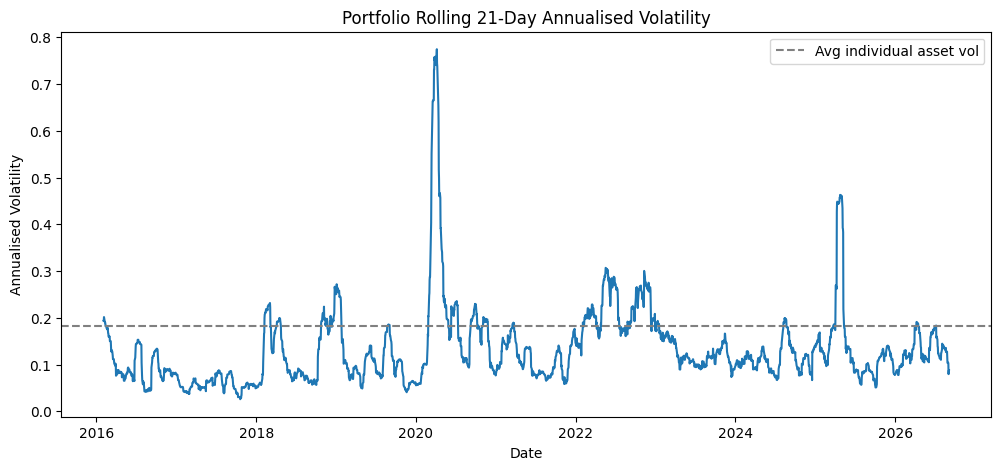

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(returns["Date"], rolling_volatility)
plt.title("Portfolio Rolling 21-Day Annualised Volatility")
plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.axhline(y=annual_volatility.mean(), color="gray", linestyle="--", label="Avg individual asset vol")
plt.legend()
plt.show()

In [38]:
import numpy as np

num_portfolios = 10000
num_assets = 5
asset_names = ["SPY", "QQQ", "TLT", "GLD", "VNQ"]

results = np.zeros((3, num_portfolios))  # row 0: return, row 1: volatility, row 2: Sharpe
weights_record = []

np.random.seed(42)

In [39]:
for i in range(num_portfolios):
    weights_random = np.random.random(num_assets)
    weights_random /= np.sum(weights_random)  # normalise so they sum to 1
    weights_record.append(weights_random)

    port_return = np.sum(returns[asset_names].mean() * weights_random) * 252
    port_volatility = np.sqrt(
        np.dot(weights_random.T, np.dot(returns[asset_names].cov() * 252, weights_random))
    )
    sharpe = (port_return - risk_free_rate) / port_volatility

    results[0, i] = port_return
    results[1, i] = port_volatility
    results[2, i] = sharpe

In [40]:
results.shape

(3, 10000)

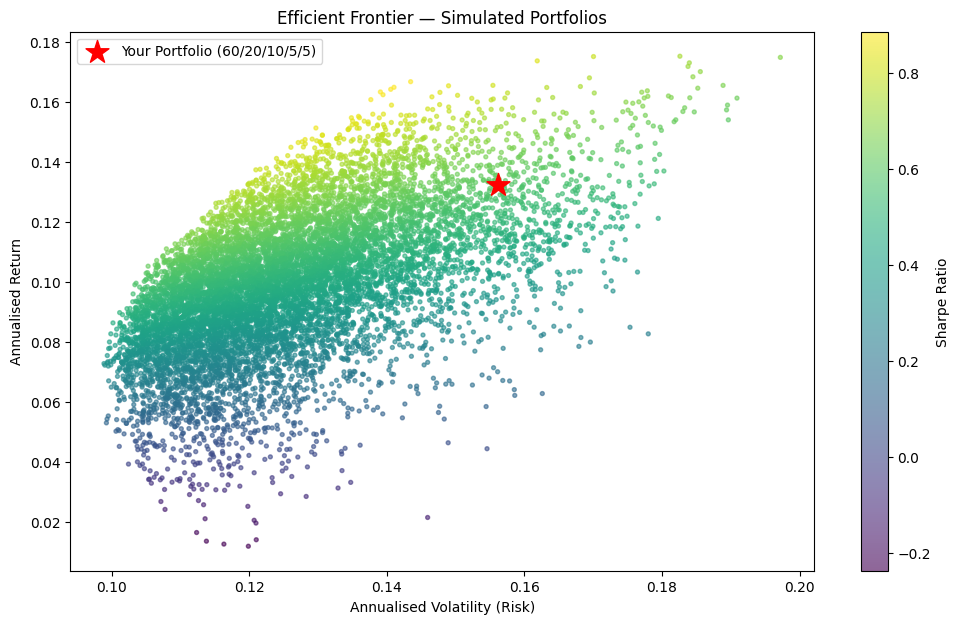

In [41]:
plt.figure(figsize=(12, 7))
plt.scatter(results[1], results[0], c=results[2], cmap="viridis", s=8, alpha=0.6)
plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Annualised Volatility (Risk)")
plt.ylabel("Annualised Return")
plt.title("Efficient Frontier — Simulated Portfolios")

# Mark your original fixed-weight portfolio for comparison
plt.scatter(portfolio_annual_volatility, portfolio_annual_return, 
            color="red", marker="*", s=300, label="Your Portfolio (60/20/10/5/5)")

plt.legend()
plt.show()

In [42]:
max_sharpe_index = np.argmax(results[2])

max_sharpe = results[2, max_sharpe_index]
max_sharpe_return = results[0, max_sharpe_index]
max_sharpe_volatility = results[1, max_sharpe_index]

max_sharpe_weights = weights_record[max_sharpe_index]

In [43]:
print("Maximum Sharpe Ratio:", round(max_sharpe, 2))
print("Expected Return:", round(max_sharpe_return * 100, 2), "%")
print("Volatility:", round(max_sharpe_volatility * 100, 2), "%")

for asset, weight in zip(asset_names, max_sharpe_weights):
    print(asset, ":", round(weight * 100, 2), "%")

Maximum Sharpe Ratio: 0.89
Expected Return: 16.32 %
Volatility: 13.91 %
SPY : 0.37 %
QQQ : 47.0 %
TLT : 3.36 %
GLD : 47.83 %
VNQ : 1.43 %


In [44]:
min_vol_index = np.argmin(results[1])

min_volatility = results[1, min_vol_index]
min_vol_return = results[0, min_vol_index]
min_vol_sharpe = results[2, min_vol_index]

min_vol_weights = weights_record[min_vol_index]

In [45]:
print("Minimum Volatility:", round(min_volatility * 100, 2), "%")
print("Expected Return:", round(min_vol_return * 100, 2), "%")
print("Sharpe Ratio:", round(min_vol_sharpe, 2))

for asset, weight in zip(asset_names, min_vol_weights):
    print(asset, ":", round(weight * 100, 2), "%")

Minimum Volatility: 9.89 %
Expected Return: 7.27 %
Sharpe Ratio: 0.33
SPY : 26.61 %
QQQ : 0.99 %
TLT : 40.81 %
GLD : 30.08 %
VNQ : 1.5 %


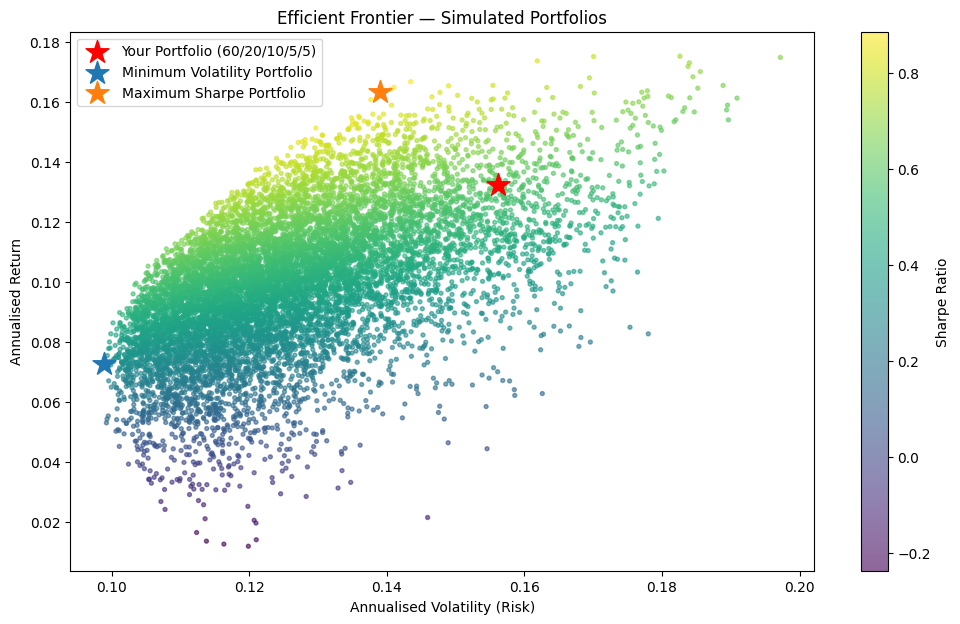

In [46]:
plt.figure(figsize=(12, 7))

plt.scatter(
    results[1],
    results[0],
    c=results[2],
    cmap="viridis",
    s=8,
    alpha=0.6
)

plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Annualised Volatility (Risk)")
plt.ylabel("Annualised Return")
plt.title("Efficient Frontier — Simulated Portfolios")

# Your original fixed-weight portfolio
plt.scatter(
    portfolio_annual_volatility,
    portfolio_annual_return,
    color="red",
    marker="*",
    s=300,
    label="Your Portfolio (60/20/10/5/5)"
)

# Minimum-volatility portfolio
plt.scatter(
    min_volatility,
    min_vol_return,
    marker="*",
    s=300,
    label="Minimum Volatility Portfolio"
)

# Maximum-Sharpe portfolio
plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

plt.legend()
plt.show()

In [47]:
optimized_weights = pd.DataFrame({
    "Asset": asset_names,
    "Minimum Volatility": min_vol_weights,
    "Maximum Sharpe": max_sharpe_weights
})

optimized_weights

,Asset,Minimum Volatility,Maximum Sharpe
0,SPY,0.266104,0.003709
1,QQQ,0.009945,0.470004
2,TLT,0.408134,0.033631
3,GLD,0.300826,0.478309
4,VNQ,0.014990,0.014346


In [48]:
optimized_weights["Minimum Volatility"] = (
    optimized_weights["Minimum Volatility"] * 100
).round(2)

optimized_weights["Maximum Sharpe"] = (
    optimized_weights["Maximum Sharpe"] * 100
).round(2)

optimized_weights

,Asset,Minimum Volatility,Maximum Sharpe
0,SPY,26.61,0.37
1,QQQ,0.99,47.00
2,TLT,40.81,3.36
3,GLD,30.08,47.83
4,VNQ,1.50,1.43


In [49]:
num_simulations = 1000
num_days = 252  # simulate 1 trading year forward

mean_daily_return = portfolio_returns.mean()
daily_volatility = portfolio_returns.std()

simulated_paths = np.zeros((num_days, num_simulations))

In [50]:
simulated_paths.shape

(252, 1000)

In [51]:
np.random.seed(42)

for sim in range(num_simulations):
    daily_returns_sim = np.random.normal(mean_daily_return, daily_volatility, num_days)
    price_path = (1 + daily_returns_sim).cumprod()
    simulated_paths[:, sim] = price_path

In [52]:
simulated_paths[:, :5]

array([[1.00541163, 1.02140386, 0.99412313, 1.00537821, 1.01085084],
       [1.00457137, 1.03231524, 0.98988014, 1.00773397, 1.00605798],
       [1.01149992, 1.0174251 , 0.98463003, 0.99975219, 1.01962573],
       ...,
       [1.12069007, 1.20908718, 0.9162577 , 1.60833873, 1.44032292],
       [1.10737532, 1.19308433, 0.90817974, 1.62334798, 1.43108786],
       [1.11795649, 1.20031859, 0.93217733, 1.63434433, 1.43105339]])

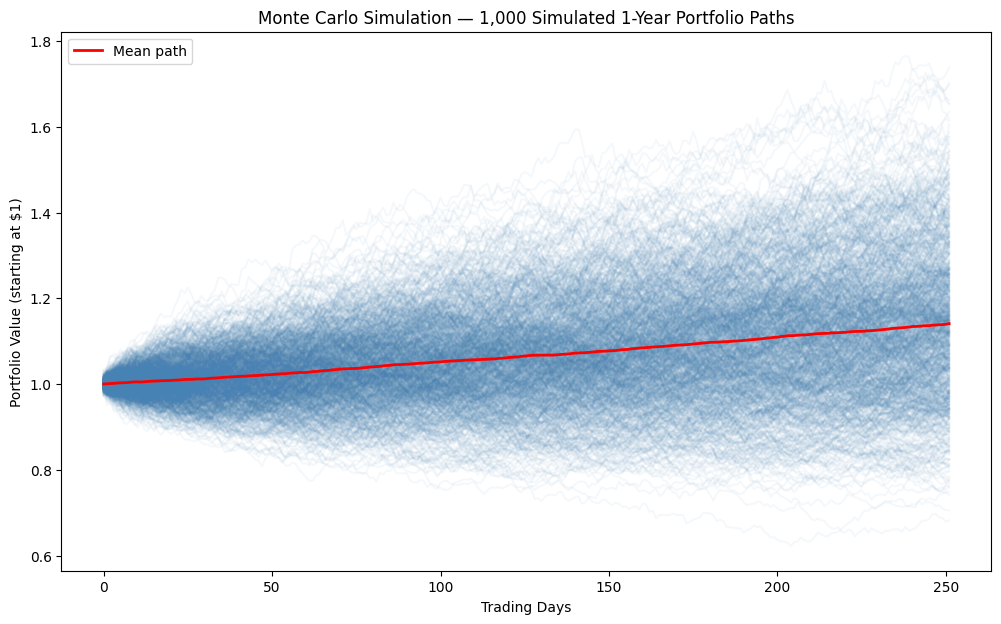

In [53]:
plt.figure(figsize=(12, 7))
plt.plot(simulated_paths, color="steelblue", alpha=0.05)
plt.plot(simulated_paths.mean(axis=1), color="red", linewidth=2, label="Mean path")
plt.title("Monte Carlo Simulation — 1,000 Simulated 1-Year Portfolio Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value (starting at $1)")
plt.legend()
plt.show()

In [54]:
final_values = simulated_paths[-1, :]  # portfolio value at end of year, across all 1000 sims

percentiles = np.percentile(final_values, [5, 25, 50, 75, 95])
percentiles

array([0.87268609, 1.01163014, 1.13438343, 1.2491898 , 1.45344064])

In [55]:
VaR_95 = 1 - percentiles[0]  # 5th percentile
round(VaR_95, 4)

np.float64(0.1273)

In [56]:
worst_5pct = final_values[final_values <= np.percentile(final_values, 5)]
CVaR_95 = 1 - worst_5pct.mean()
round(CVaR_95, 4)

np.float64(0.1818)

In [57]:
summary = {
    "Annualised Return": round(portfolio_annual_return, 4),
    "Annualised Volatility": round(portfolio_annual_volatility, 4),
    "Sharpe Ratio": round(sharpe_ratio, 4),
    "Max Drawdown": round(max_drawdown(portfolio_returns), 4),
    "VaR (95%, 1yr)": round(VaR_95, 4),
    "CVaR (95%, 1yr)": round(CVaR_95, 4)
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Annualised Return,0.1322
1,Annualised Volatility,0.1562
2,Sharpe Ratio,0.5903
3,Max Drawdown,-0.2769
4,"VaR (95%, 1yr)",0.1273
5,"CVaR (95%, 1yr)",0.1818


In [58]:
cov_matrix = returns[asset_names].cov() * 252
weights_array = np.array([weights[a] for a in asset_names])

portfolio_variance = np.dot(weights_array.T, np.dot(cov_matrix, weights_array))

marginal_contribution = np.dot(cov_matrix, weights_array)
risk_contribution = weights_array * marginal_contribution / portfolio_variance

risk_contribution_pct = pd.Series(risk_contribution * 100, index=asset_names).round(2)
risk_contribution_pct

SPY    67.42
QQQ    27.20
TLT    -0.22
GLD     0.87
VNQ     4.73
dtype: float64

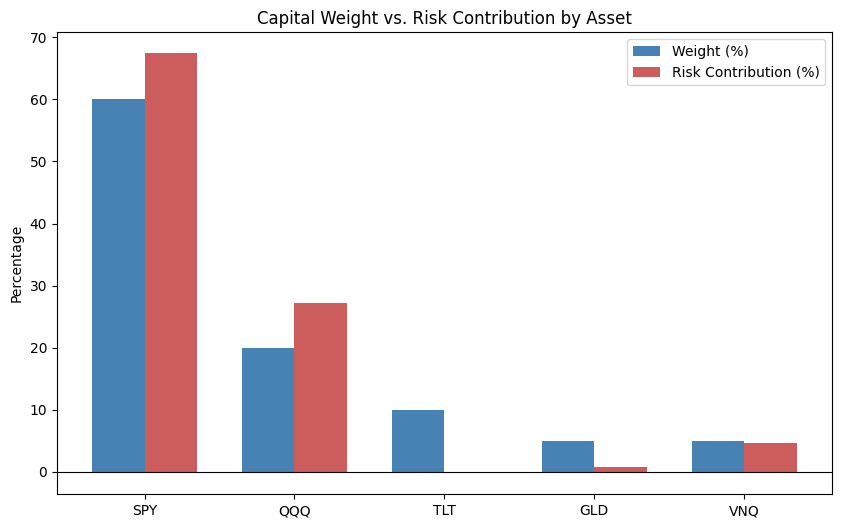

In [59]:
import matplotlib.pyplot as plt
import numpy as np

weights_pct = pd.Series(weights) * 100

comparison_df = pd.DataFrame({
    "Weight (%)": weights_pct,
    "Risk Contribution (%)": risk_contribution_pct
})

x = np.arange(len(asset_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, comparison_df["Weight (%)"], width, label="Weight (%)", color="steelblue")
plt.bar(x + width/2, comparison_df["Risk Contribution (%)"], width, label="Risk Contribution (%)", color="indianred")

plt.axhline(y=0, color="black", linewidth=0.8)
plt.xticks(x, asset_names)
plt.ylabel("Percentage")
plt.title("Capital Weight vs. Risk Contribution by Asset")
plt.legend()
plt.show()

In [61]:
def generate_narrative(risk_contribution_pct, weights_pct, sharpe_ratio, max_dd, var_95, cvar_95):
    # Find the biggest risk contributor
    top_risk_asset = risk_contribution_pct.idxmax()
    top_risk_value = risk_contribution_pct.max()
    top_weight_value = weights_pct[top_risk_asset]

    # Find any asset with negative risk contribution (a hedge)
    hedges = risk_contribution_pct[risk_contribution_pct < 0]

    narrative = []

    narrative.append(
        f"{top_risk_asset} makes up {top_weight_value:.0f}% of your portfolio's capital, "
        f"but contributes {top_risk_value:.0f}% of its total risk."
    )

    if len(hedges) > 0:
        hedge_names = ", ".join(hedges.index)
        verb = "reduces" if len(hedges) == 1 else "reduce"
        narrative.append(
            f"{hedge_names} currently {verb} your overall portfolio risk, acting as a hedge rather than added exposure."
        )

    narrative.append(
        f"Your portfolio has a Sharpe ratio of {sharpe_ratio:.2f}, meaning "
        f"you earn {sharpe_ratio:.2f} units of return for every unit of risk taken."
    )

    narrative.append(
        f"Historically, this portfolio's worst peak-to-trough decline was {max_dd*100:.1f}%."
    )

    narrative.append(
        f"There's a 5% chance of losing more than {var_95*100:.1f}% in a given year — "
        f"and if that happens, the average loss in that worst-case group is closer to {cvar_95*100:.1f}%."
    )

    return "\n\n".join(narrative)

print(generate_narrative(risk_contribution_pct, weights_pct, sharpe_ratio, max_drawdown(portfolio_returns), VaR_95, CVaR_95))

SPY makes up 60% of your portfolio's capital, but contributes 67% of its total risk.

TLT currently reduces your overall portfolio risk, acting as a hedge rather than added exposure.

Your portfolio has a Sharpe ratio of 0.59, meaning you earn 0.59 units of return for every unit of risk taken.

Historically, this portfolio's worst peak-to-trough decline was -27.7%.

There's a 5% chance of losing more than 12.7% in a given year — and if that happens, the average loss in that worst-case group is closer to 18.2%.
